# Notebook métricas de evaluación con RR Lyrae

Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)

En esta actividad trabajaremos con un problema de clasificación binaria: distinguir estrellas **RR Lyrae** de otras estrellas a partir de sus colores fotométricos.

### Los objetivos son
- entrenar un clasificador simple
- evaluar su rendimiento con distintas métricas
- interpretar una matriz de confusión
- comparar accuracy con precision, recall y F1
- discutir qué métrica conviene según el objetivo científico

### Contexto
Las RR Lyrae son estrellas variables pulsantes muy importantes en astronomía. En un catálogo grande, un clasificador puede ayudarnos a encontrar candidatas RR Lyrae, pero no basta con mirar solo el accuracy.


### Descripción de los datos
El set de datos que usará para esta tarea es sobre estrellas. Las características son colores en distintos filtros del [sistema ugriz de SDSS](https://www.physics.unlv.edu/~jeffery/astro/photometry/photometry_sdss.html), que son un indicador si la estrella emite luz más azul, verde, amarilla o roja. Queremos predecir a partir de estas características si la estrella es un tipo especial de estrella llamada variable RR Lyrae.

- Las características son los colores u-g, g-r, r-i, i-z
- El target es 0 (no RRLyrae) y 1 (RRLyrae)


In [62]:
import pandas as pd
import numpy as np

import sklearn.tree
from sklearn.tree import DecisionTreeClassifier #modelo
from sklearn.tree import plot_tree #visualizacion arbol
from sklearn.model_selection import train_test_split
from sklearn import metrics #métricas
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate #validación cruzada
from sklearn.model_selection import KFold, StratifiedKFold #validación cruzada

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay #matriz de confusión


from scipy import stats

In [63]:
from io import StringIO
from IPython.display import Image
import pydotplus
from sklearn.tree import export_graphviz

In [64]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

font = {'size': 8}

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=8)
matplotlib.rc('ytick', labelsize=8)
matplotlib.rcParams['figure.dpi'] = 300

pd.set_option('display.max_columns', 100) #Para poder visualizar todas las columnas del dataframe
pd.set_option('display.max_colwidth', 100)

## Primer paso: exploración de los datos

Siempre es importante hacer una análisis exploratorio del conjunto de datos que trabajaremos. Leemos el archivo como un dataframe y extraemos información básica

In [65]:

#cargamos los datos como arreglos numpy
features = np.loadtxt("RRLyrae_features_small.txt", delimiter=',')
targets = np.loadtxt("RRLyrae_labels_small.txt", delimiter=',')

In [66]:
columnas = ["u-g", "g-r", "r-i", "i-z"]
df = pd.DataFrame(features, columns=columnas)
df["RR_Lyrae"] = targets.astype(int)

df.head()

,u-g,g-r,r-i,i-z,RR_Lyrae
0,0.311,0.714,0.093,0.204,0
1,0.332,0.965,0.122,0.032,0
2,0.394,1.019,0.147,0.096,0
3,0.285,0.865,0.120,0.039,0
4,0.386,0.977,0.181,0.080,0


### Preguntas
1. ¿Este es un problema de clasificación o regresión?
2. ¿Es un problema binario o multiclase?
3. ¿Qué representa la variable objetivo?
4. ¿Las clases están balanceadas o desbalanceadas?
5. ¿Por qué esto podría ser importante al elegir una métrica de evaluación?

1. Ya que buscamos predecir categorias para los datos, el problema debe ser de clasificación.

2. Como son 2 posibles soluciones en un problema binario

3. El tipo de eestrella al que corresponde, en este caso seria RR_Lyrae, que se divide en 0 y 1, si es o no es.

4. Si esta balanceado o no dependera de la cantidad de la muestra, y como se distribuye, en este caso ya que son muchos los datos, y estos no de sitribuyen de forma pareja la muestra esta desbalanceada.

5. Ya que los resultados pueden tener un mal accuracy, por ejemplo si detecta mas RR_Lyrae tendria un accuracy alto, pero no serviria para un analisis.

#### Haga una visualización de sólo dos columnas para revisar los colores de las RR Lyrae y las no RRLyrae

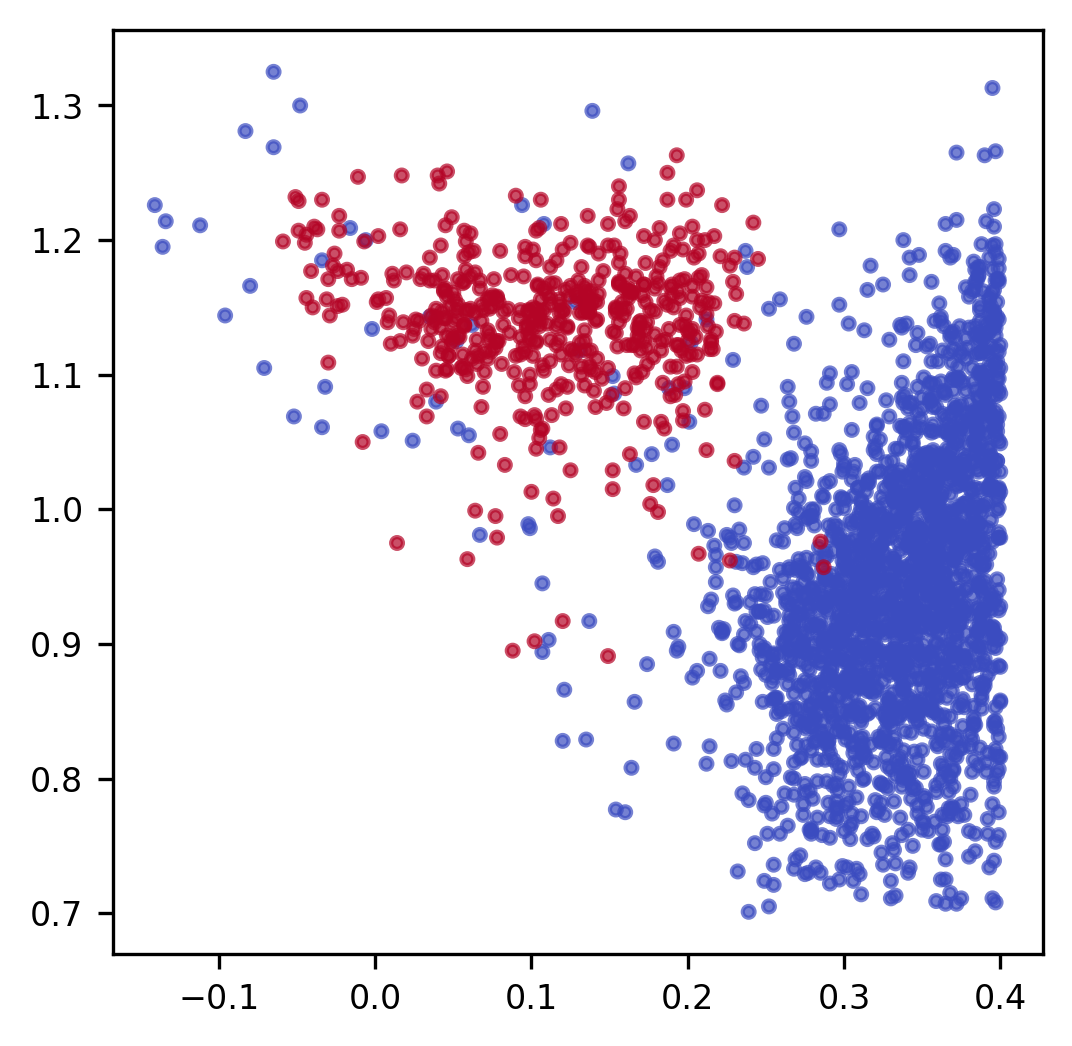

In [67]:
import matplotlib.pyplot as plt

#complete la celda
plt.figure(figsize=(4,4))

sc=plt.scatter(df['u-g'], df['g-r'], c=df['RR_Lyrae'], cmap='coolwarm', s=8, alpha=0.7)
plt.show()

### Pregunta
1. ¿Se observan regiones donde las clases parecen separarse?
2. A simple vista, ¿esperarías que un árbol de decisión funcione razonablemente bien?

**RESPUESTAS**
1. Exsiten regiones marcadas donde se ve una distribucion clara entre los 2 tipos, aún así esta no esta completamente delimitada y tiene datos que se combinan.

2. No esperaria que un arbol de decisión funcione del todo bien, ya que tal y como dije hay mucha cantidad de datos que están distribuidos en las zonas de la otra variable. Aun así se logra observar bien la distribución por lo que no esperaria que funcione mal.

#### Separe los datos en entrenamiento y prueba

In [68]:
X = df[["u-g", "g-r", "r-i", "i-z"]]
y = df["RR_Lyrae"]

In [69]:
#complete la celda
X_train, X_test, y_train, y_test =train_test_split(X,y,test_size=0.3, random_state=42)

In [70]:
X_train.shape

(1738, 4)

### Antes de continuar

Las clases en este problema no están perfectamente balanceadas.

Piense en la forma en que podríamos separar los datos en entrenamiento y prueba, y responda:

1. ¿Qué problema podría ocurrir si hacemos la partición de manera completamente aleatoria, sin preocuparnos por la proporción de clases?
2. ¿Por qué eso podría afectar la evaluación del modelo?
3. ¿Qué tipo de precaución cree que sería razonable tomar al construir los conjuntos de entrenamiento y prueba en este caso?

**RESPUESTAS**
1. Si hacemos las particiones sin ver la proporcion, se podria distribuir de mala manera los datos, ya que están mal distribuidos. Por ejemplo si queda una partición con pocos datos, puede que la mayoria de datos que buscamos terminen siendo de prueba y nada para el entrenamiento.

2. Afecta a el analisis ya que primero el grupo de prueba deja se der representativo, o el grupo de entrenamiento, generando que el modelo en si no logre clasificar nada bien.

3. Se deberia ver bien la estrtificacion o la particion de la muestra para lograr buenos datos de entrenamiento y prueba y que estos tengan una bunea cantidad.


#### Ahora entrenaremos un árbol de decisión (modelo base)

In [71]:
model_tree = DecisionTreeClassifier(random_state=42)
model_tree.fit(X_train, y_train)
#entrene el modelo y genere las predicciones
y_pred=model_tree.predict(X_test)


#### Visualicemos el árbol

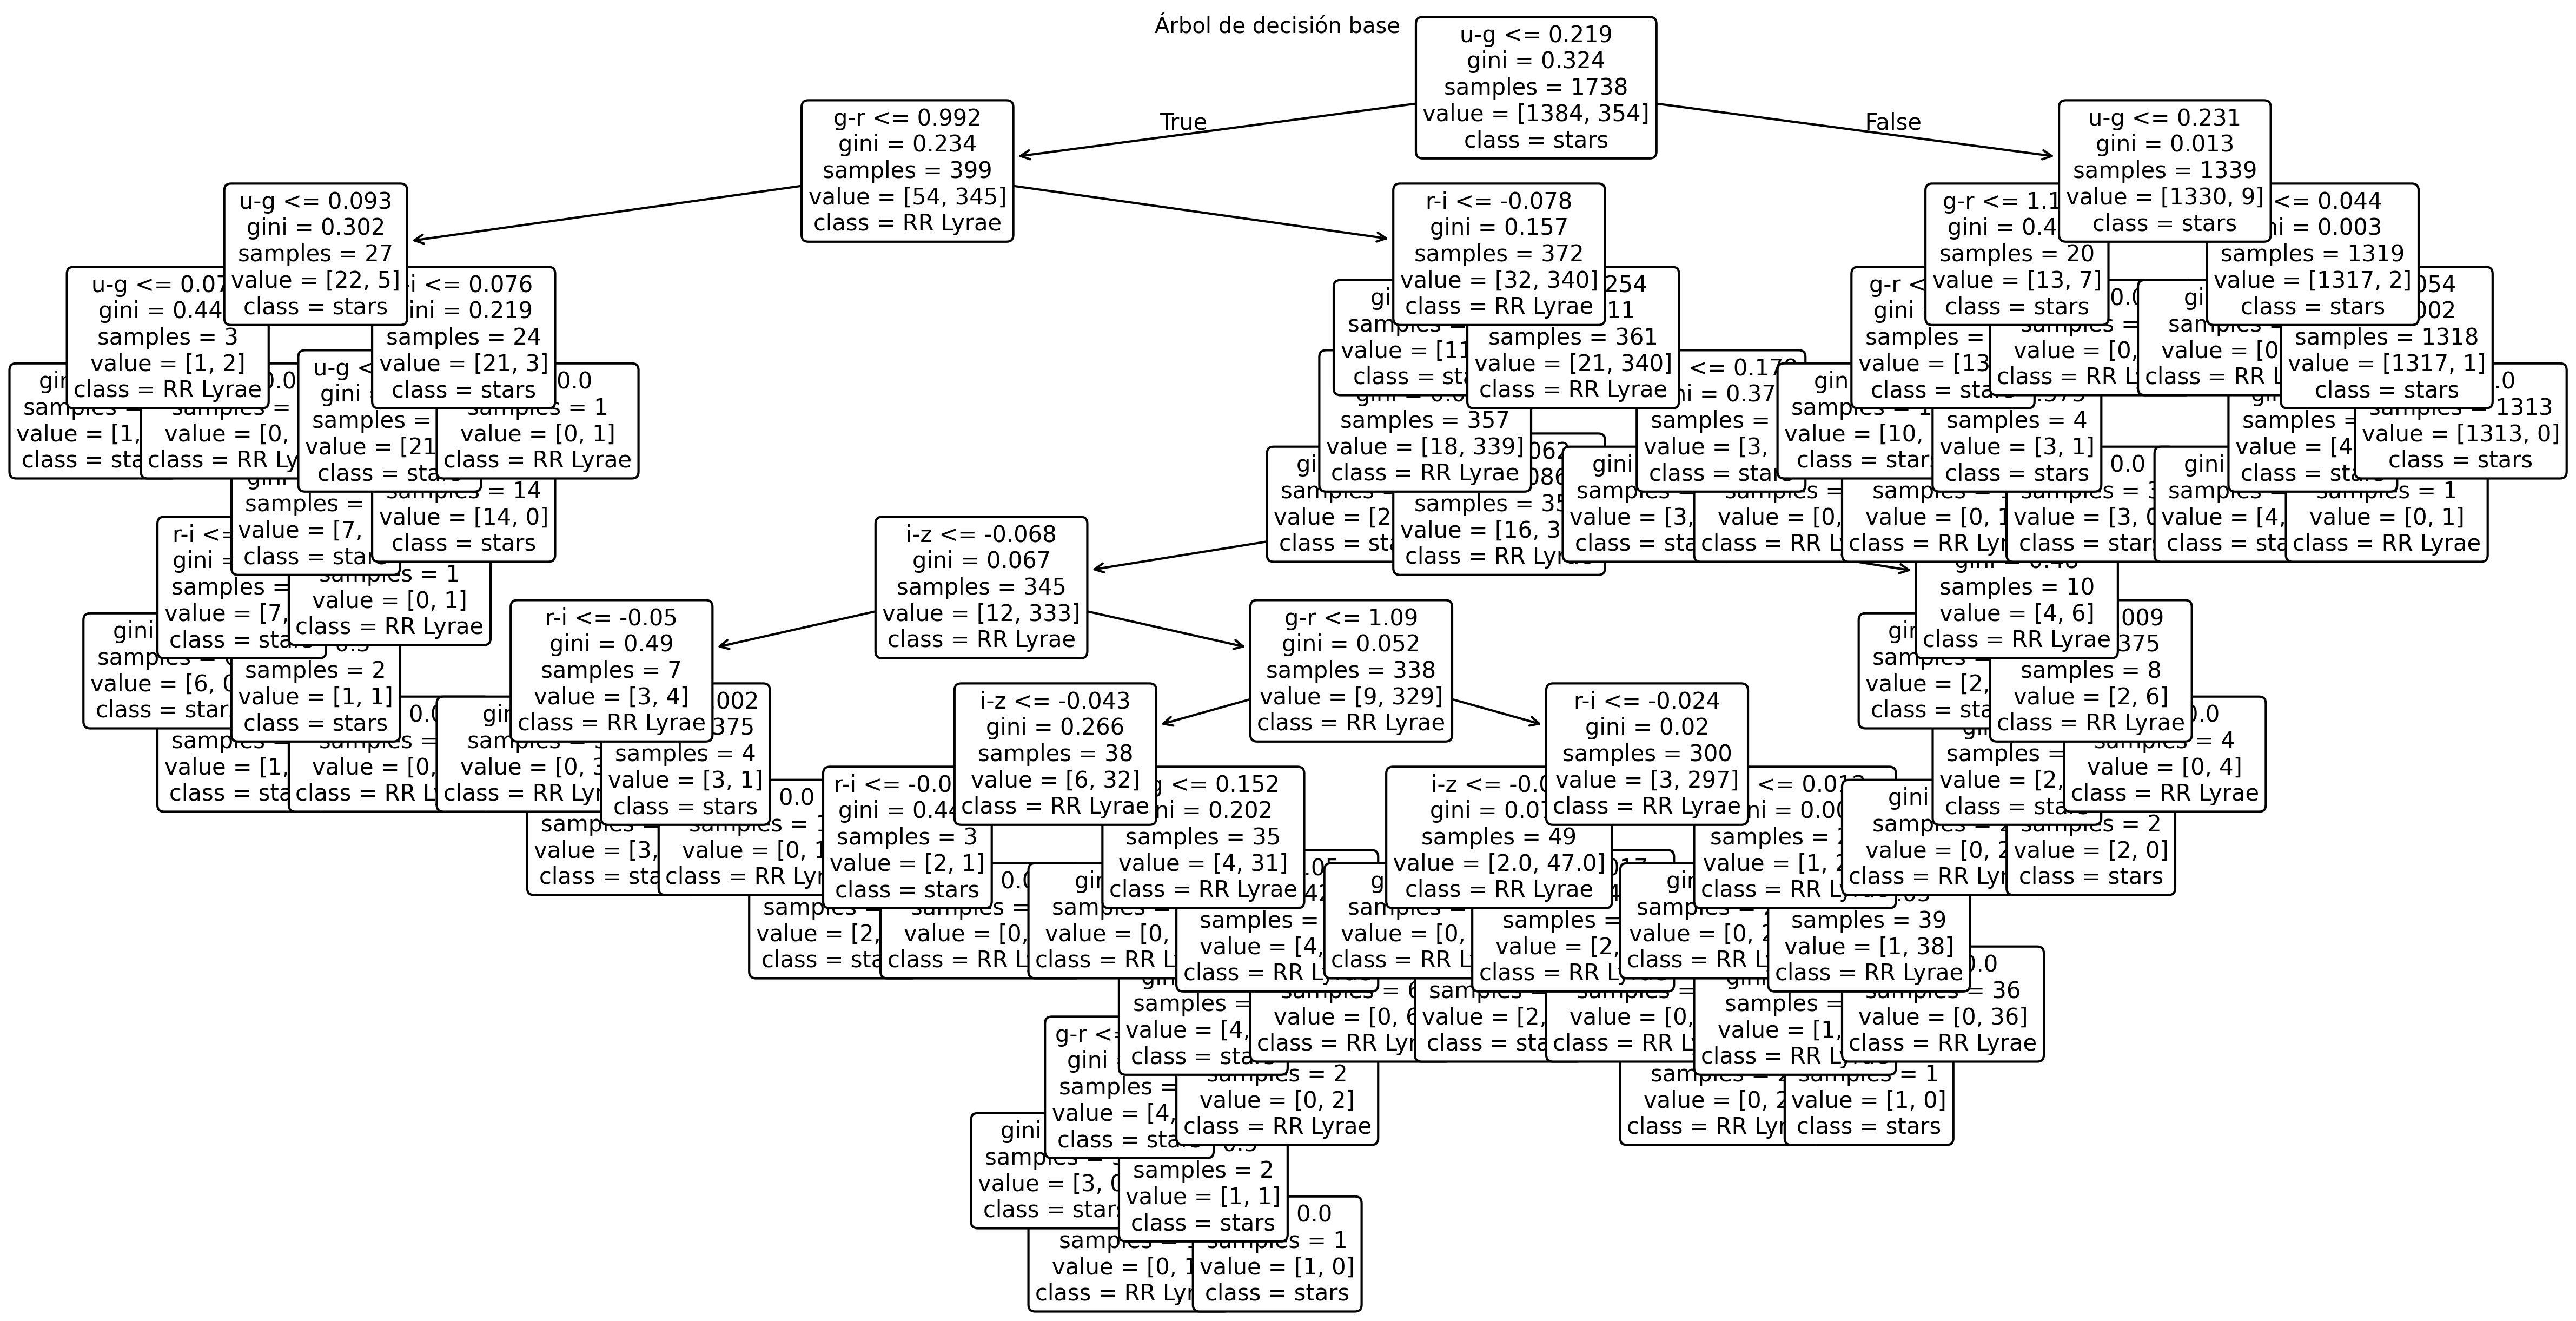

In [72]:
plt.figure(figsize=(20,10))

plot_tree(
    model_tree,
    feature_names=X.columns,
    class_names=["stars", "RR Lyrae"],
    filled=False,
    rounded=True,
    #max_depth=3,
    fontsize=10
)

plt.title("Árbol de decisión base")
plt.show()

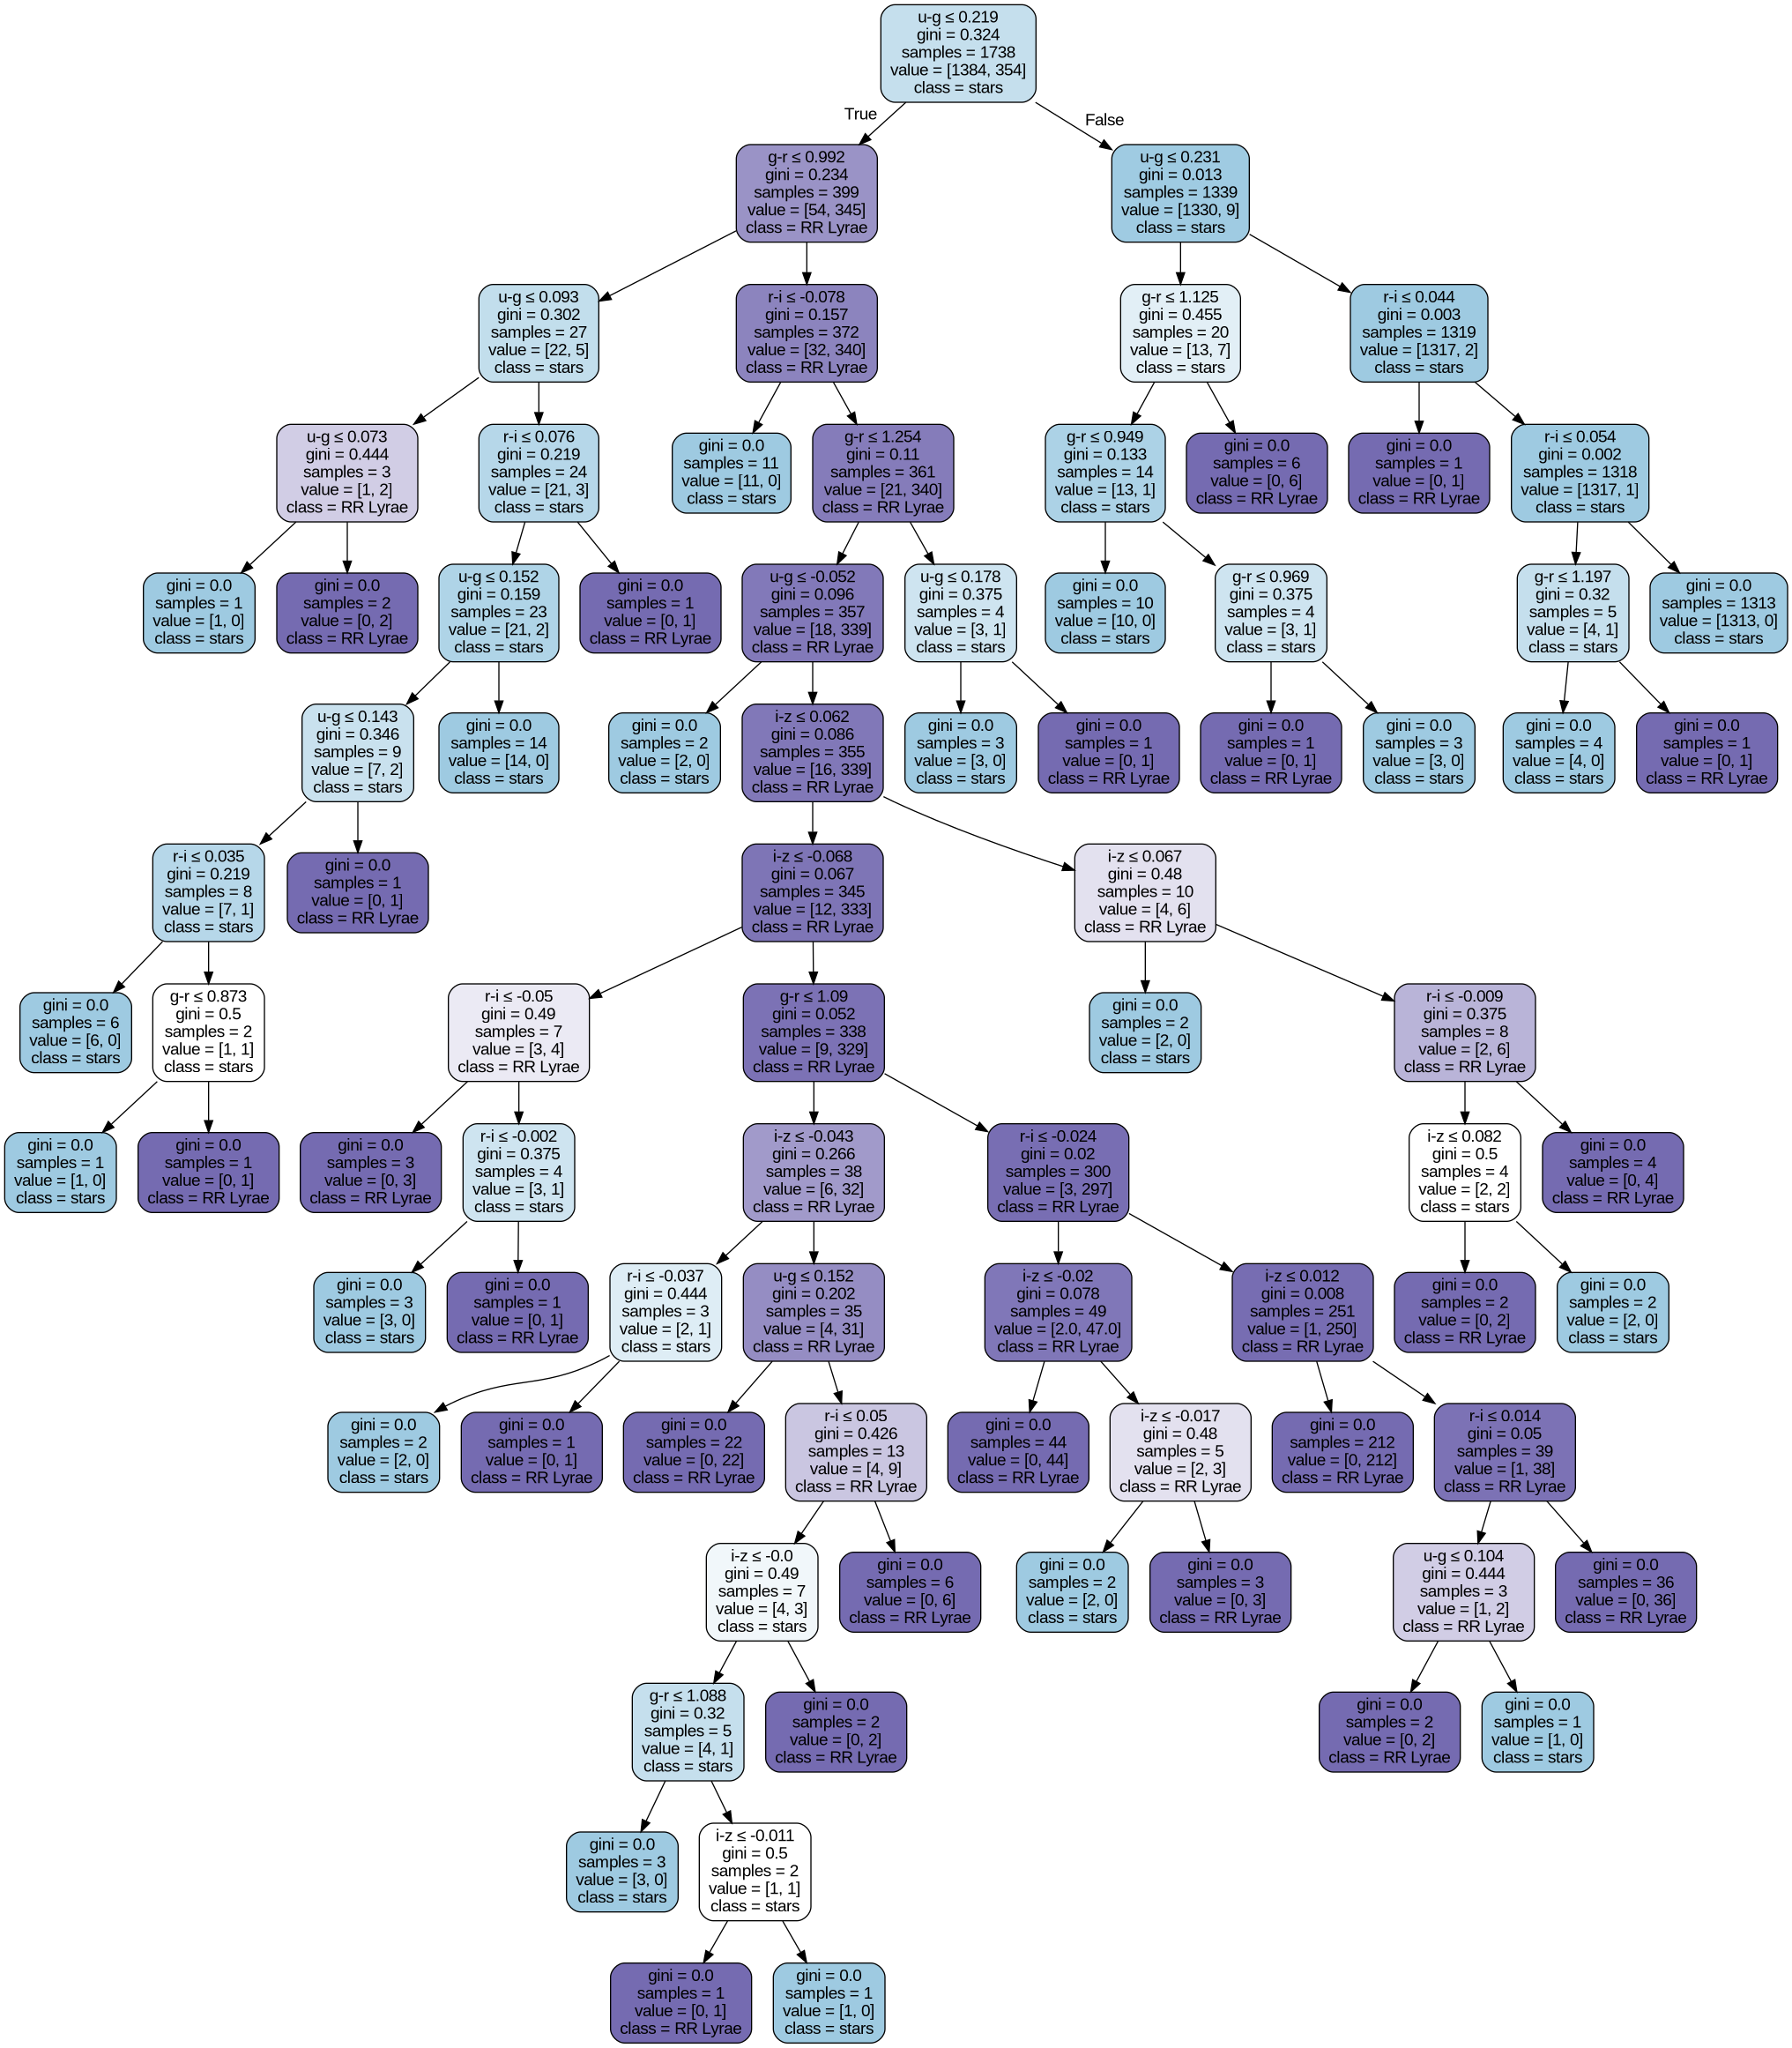

In [73]:
# Recordatorio: Las características siempre se permutan aleatoriamente en cada división.
# Por lo tanto, la mejor división encontrada puede variar, incluso con los mismos datos
# de entrenamiento y max_features=n_features, si la mejora del criterio es idéntica
# para varias divisiones enumeradas durante la búsqueda de la mejor división.
# Para obtener un comportamiento determinista durante el ajuste, random_state debe estar fijo.

dot_data = StringIO()

export_graphviz(
    model_tree,
    out_file=dot_data,
    feature_names=['u-g', 'g-r', 'r-i', 'i-z'],
    class_names=['stars', 'RR Lyrae'],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = pydotplus.graph_from_dot_data(dot_data.getvalue().replace("\n", ""))
nodes = graph.get_node_list()

for node in nodes:
    if node.get_label() and 'value = [' in node.get_label():

        values = [float(ii) for ii in node.get_label().split('value = [')[1].split(']')[0].split(',')]
        values = [int(255 * v / sum(values)) for v in values]

        if values[0] > values[1]:
            alpha = int(values[0] - values[1])
            alpha = '{:02x}'.format(alpha)
            color = '#9ecae1' + str(alpha)   # turquesa
        else:
            alpha = int(values[1] - values[0])
            alpha = '{:02x}'.format(alpha)
            color = '#756bb1' + str(alpha)   # magenta

        node.set_fillcolor(color)

Image(graph.create_png())

### Preguntas

Observe la estructura del árbol y responda brevemente:

1. ¿El árbol parece muy simple o bastante complejo? Justifique a partir del número de niveles o divisiones.
2. ¿Qué desventaja podría tener un árbol demasiado grande en un problema como este?

**RESPUESTAS**

1. El arbol es muy profundo y para nada simple, vemos más de 10 niveles y 10 divisiones, lo que hace que sea un arbol complejo.

2. La desventaja principal es que el modelo deja de aprender a clasificar y comeinza a memorizar, haciendo que no cumpla con su objetivo.

#### Miremos las métricas accuracy para set de entrenamiento y prueba

In [74]:
print(metrics.accuracy_score(y_train, model_tree.predict(X_train))) #train score

print(metrics.accuracy_score(y_test, model_tree.predict(X_test))) #test score

1.0
0.9651006711409396


#### Otras métricas

In [75]:
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall   :", metrics.recall_score(y_test, y_pred))
print("F1-score :", metrics.f1_score(y_test, y_pred))

Precision: 0.8759124087591241
Recall   : 0.9302325581395349
F1-score : 0.9022556390977443


In [76]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[599,  17],
       [  9, 120]])

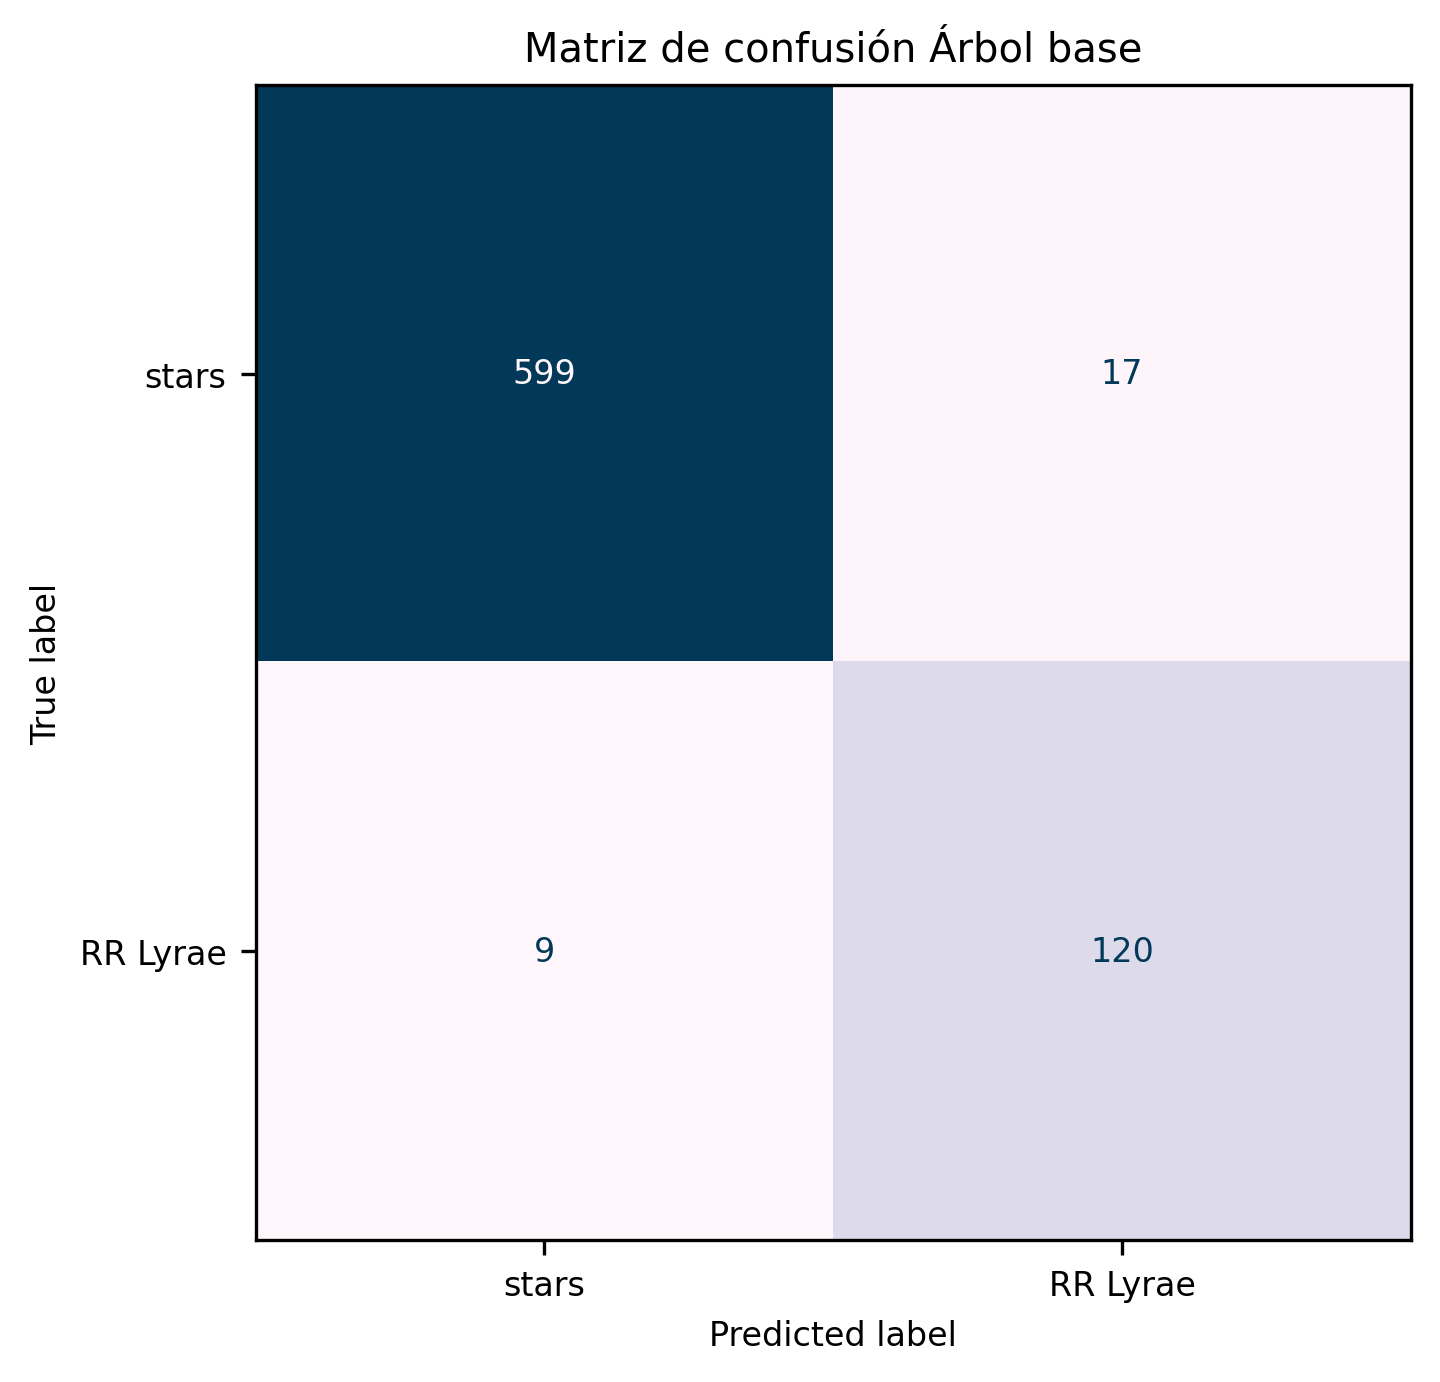

In [77]:
fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["stars", "RR Lyrae"])
disp.plot(cmap="PuBu", ax=ax, colorbar=False)

plt.title("Matriz de confusión Árbol base")
plt.show()

#### A partir de la matriz de confusión obtenida:
1.  Identifique los valores de:
   - verdaderos positivos (TP)
   - verdaderos negativos (TN)
   - falsos positivos (FP)
   - falsos negativos (FN)
2. Calcule las métricas "a mano"



**RESPUESTA**

1. TP=120

  TN=599

  FP=17

  FN=9

2. Accuracy: (120 + 599) / 745 = 0.965

Precision: 120 / (120 + 17) = 0.876

Recall: 120 / (120 + 9) = 0.930

F1-Score: 2 * (0.876 * 0.930) / (0.876 + 0.930) = 0.902

### Preguntas
1. Explique con sus palabras qué significa, en este problema:
   - un falso positivo
   - un falso negativo

2. Si el objetivo científico fuera encontrar la mayor cantidad posible de RR Lyrae, ¿qué tipo de error preocuparía más?

3. Si el objetivo fuera construir una muestra final más limpia, ¿qué tipo de error preocuparía más?

**RESPUESTAS**

1. Un falso positivo seria cuando el modelo dice que la estrella es RR Lyrae cuando en realidad no lo es (0)
Un falso negativo seria lo contrario, predice que no es una RR Lyrae es decir un 0 cuando en realidad si es, un 1.

2. El falso negativo seria el error más preocupante, ya que no clasificaria bien las estrellas que estoy juntando, dejando fuera los datos que busco.

3. Pasa una muestra más limpia seria el falso positivo ya que de esa forma la muestra de estrellas que busco tendria estrellas que no corresponden, generando que la muestra no este limpia.

#### Todo parece funcionar bien, pero sólo hicimos un split. Necesitamos que el resultados sea robusto. Para esto, implementaremos Cross-validation usando [k-fold](https://scikit--learn-org.translate.goog/stable/modules/generated/sklearn.model_selection.KFold.html?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es&_x_tr_pto=tc)

In [78]:
# Esta es la versión estándar. Importante: no baraja los datos, por lo que si tus
# ejemplos positivos están todos al principio o al final, podría llevar a resultados
# desastrosos.

cv1 = KFold(n_splits = 5)

#Esta es la versión 2: se ha añadido el barajado (¡recomendado!)

cv2 = KFold(shuffle = True, n_splits = 5, random_state=5)

# LA ESTRATIFICACIÓN asegura que las distribuciones de clases en cada división se
# asemejen a las del conjunto de datos completo.

cv3 = StratifiedKFold(shuffle = True, n_splits = 5, random_state=5)


### Efecto de la estratificación: veamos el conteo de clases en cada conjunto de divisiones.

In [79]:
cv1.split(X, y)

<generator object _BaseKFold.split at 0x7993e7d12790>

In [80]:
for train, test in cv1.split(X, y):
...     print('train -  {}   |   test -  {}'.format(
...         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1503  483]   |   test -  [497]
train -  [1503  483]   |   test -  [497]
train -  [1503  483]   |   test -  [497]
train -  [1504  483]   |   test -  [496]
train -  [1987]   |   test -  [ 13 483]


In [81]:
for train, test in cv2.split(X, y):
...     print('train -  {}   |   test -  {}'.format(
...         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1600  386]   |   test -  [400  97]
train -  [1610  376]   |   test -  [390 107]
train -  [1587  399]   |   test -  [413  84]
train -  [1599  388]   |   test -  [401  95]
train -  [1604  383]   |   test -  [396 100]


In [82]:
for train, test in cv3.split(X, y):
...     print('train -  {}   |   test -  {}'.format(
...         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1600  386]   |   test -  [400  97]
train -  [1600  386]   |   test -  [400  97]
train -  [1600  386]   |   test -  [400  97]
train -  [1600  387]   |   test -  [400  96]
train -  [1600  387]   |   test -  [400  96]


### La función [`cross_validate`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html#sklearn.model_selection.cross_validate) proporciona los puntajes (especificados por el parámetro de evaluación elegido), en forma de diccionario.

In [83]:
scores1 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv1, scoring = 'accuracy')

scores2 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv2, scoring = 'accuracy')

scores3 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv3, scoring = 'accuracy')

In [84]:
scores3

{'fit_time': array([0.00959206, 0.008986  , 0.0107739 , 0.00823855, 0.00731683]),
 'score_time': array([0.0034852 , 0.00431085, 0.00298858, 0.00299931, 0.00229549]),
 'test_score': array([0.97987928, 0.96579477, 0.96780684, 0.97580645, 0.96169355])}

Solo nos interesa el 'test_score'

#### Calculamos el promedio y $\sigma$

In [85]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['test_score'].std()))

0.786 0.380


In [86]:
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['test_score'].std()))

0.967 0.013


In [87]:
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['test_score'].std()))

0.970 0.007


La validación cruzada sin barajar (`cv1`) produce un resultado muy inestable, con una desviación estándar extremadamente alta. Esto ocurre porque los datos están ordenados por clase, de modo que algunos folds no representan bien el problema completo.

Al activar el barajado (`cv2`), el rendimiento mejora drásticamente y la dispersión disminuye. Sin embargo, el método que resulta más apropiado para este problema es `StratifiedKFold` (`cv3`), ya que además de mezclar los datos, conserva aproximadamente la proporción de clases en cada fold.

En problemas de clasificación desbalanceada, esta última estrategia suele ser la más recomendable.

In [88]:
scores1 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv1, scoring = 'recall')

scores2 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv2, scoring = 'recall')

scores3 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv3, scoring = 'recall')

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricW

In [89]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['test_score'].std()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['test_score'].std()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['test_score'].std()))

nan nan
0.903 0.016
0.925 0.019


### ¿Por qué aparece este warning?

En algunos folds generados por `KFold` sin barajado, el conjunto de prueba contiene solo ejemplos de una clase. En ese caso, el recall de la clase positiva (RR Lyrae) no puede calcularse, porque no hay positivos reales en ese fold.

Esto muestra que una estrategia de partición inadecuada puede hacer que la evaluación sea inestable, engañosa o incluso inválida.

#### También extraeremos los train scores, que nos servirán cuando estemos diagnosticando el modelo a través de bias vs variance.¶

In [90]:
scores1 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv1, scoring = 'recall', \
                         return_train_score = True)

scores2 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv2, scoring = 'recall', \
                         return_train_score = True)

scores3 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv3, scoring = 'recall',
                         return_train_score = True)

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricW

In [91]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['train_score'].mean()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['train_score'].mean()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['train_score'].mean()))

nan nan
0.902 1.000
0.921 1.000


### La función  `cross_validate` es útil para calcular el puntaje, pero no produce etiquetas predichas.

#### Estas pueden obtenerse utilizando la función [`cross_val_predict`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_predict.html), que guarda las predicciones para cada uno de los k-folds de prueba y las compila juntas.


In [92]:
model1 = DecisionTreeClassifier(random_state = 3)

y_cv3 = cross_val_predict(model1, X,y, cv = cv3)
# Estas son las predicciones,
# y son independientes del parámetro de evaluación

In [93]:
metrics.confusion_matrix(targets,y_cv3)

array([[1955,   45],
       [  33,  450]])

### Sin embargo, las cosas pueden cambiar si uso un esquema de validación cruzada diferente:

In [94]:
model2 = DecisionTreeClassifier(random_state = 3)

y_cv2 = cross_val_predict(model2, X,y, cv = cv2)

In [95]:
np.sum(y_cv3-y_cv2)

np.int64(10)

In [96]:
np.sum(y_cv2)

np.int64(485)

In [97]:
np.sum(y_cv3 != y_cv2) #comparando las predicciones

np.int64(52)

In [98]:
metrics.confusion_matrix(targets,y_cv2)

array([[1955,   45],
       [  43,  440]])

In [99]:
metrics.confusion_matrix(targets,y_cv3)

array([[1955,   45],
       [  33,  450]])

In [100]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5,
                        n_jobs=-1, train_sizes=np.linspace(0.2, 1.0, 5), scoring = 'accuracy'):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 3-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like, shape (n_ticks,), dtype float or int
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the dtype is float, it is regarded as a
        fraction of the maximum size of the training set (that is determined
        by the selected validation method), i.e. it has to be within (0, 1].
        Otherwise it is interpreted as absolute sizes of the training sets.
        Note that for classification the number of samples usually have to
        be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    plt.figure(figsize=(10,6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel(str(scoring))

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring = scoring, shuffle=True, random_state=42)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Test score from cross-validation")

    plt.legend(loc="best")
    return plt

In [101]:
model = DecisionTreeClassifier(random_state = 5)

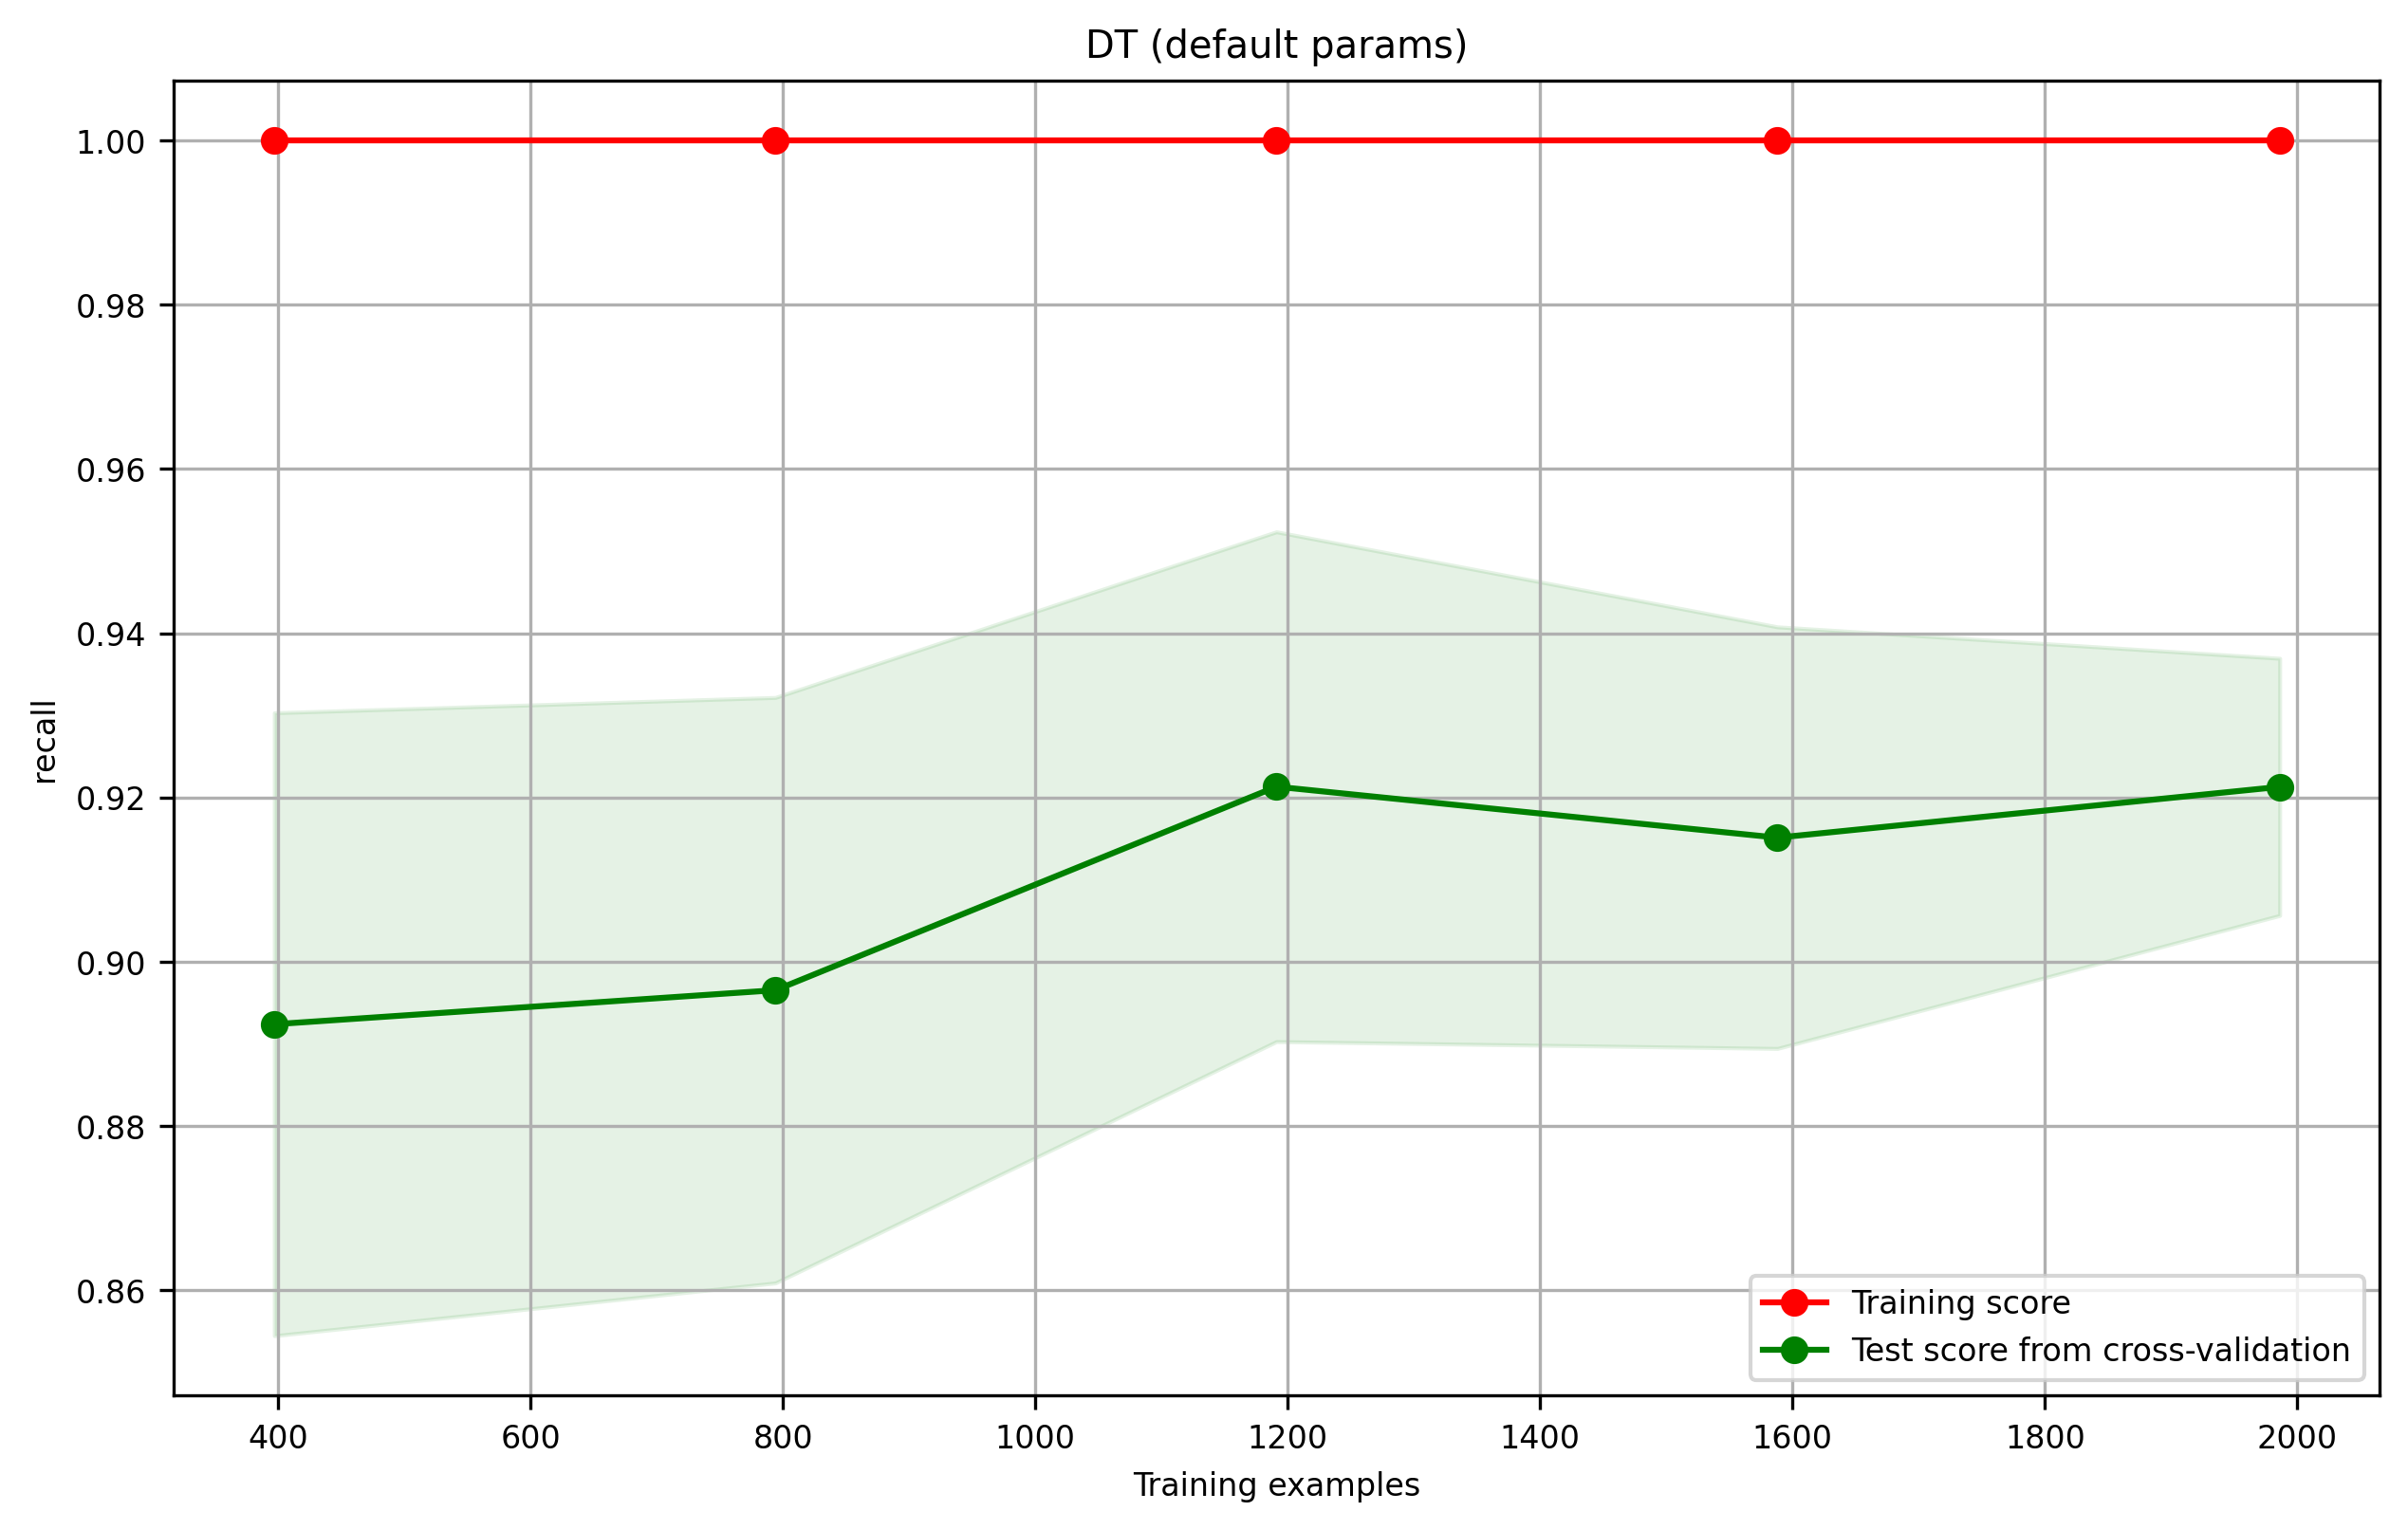

In [102]:
plot_learning_curve(model, 'DT (default params)', X, y,  cv = cv3, scoring = 'recall');

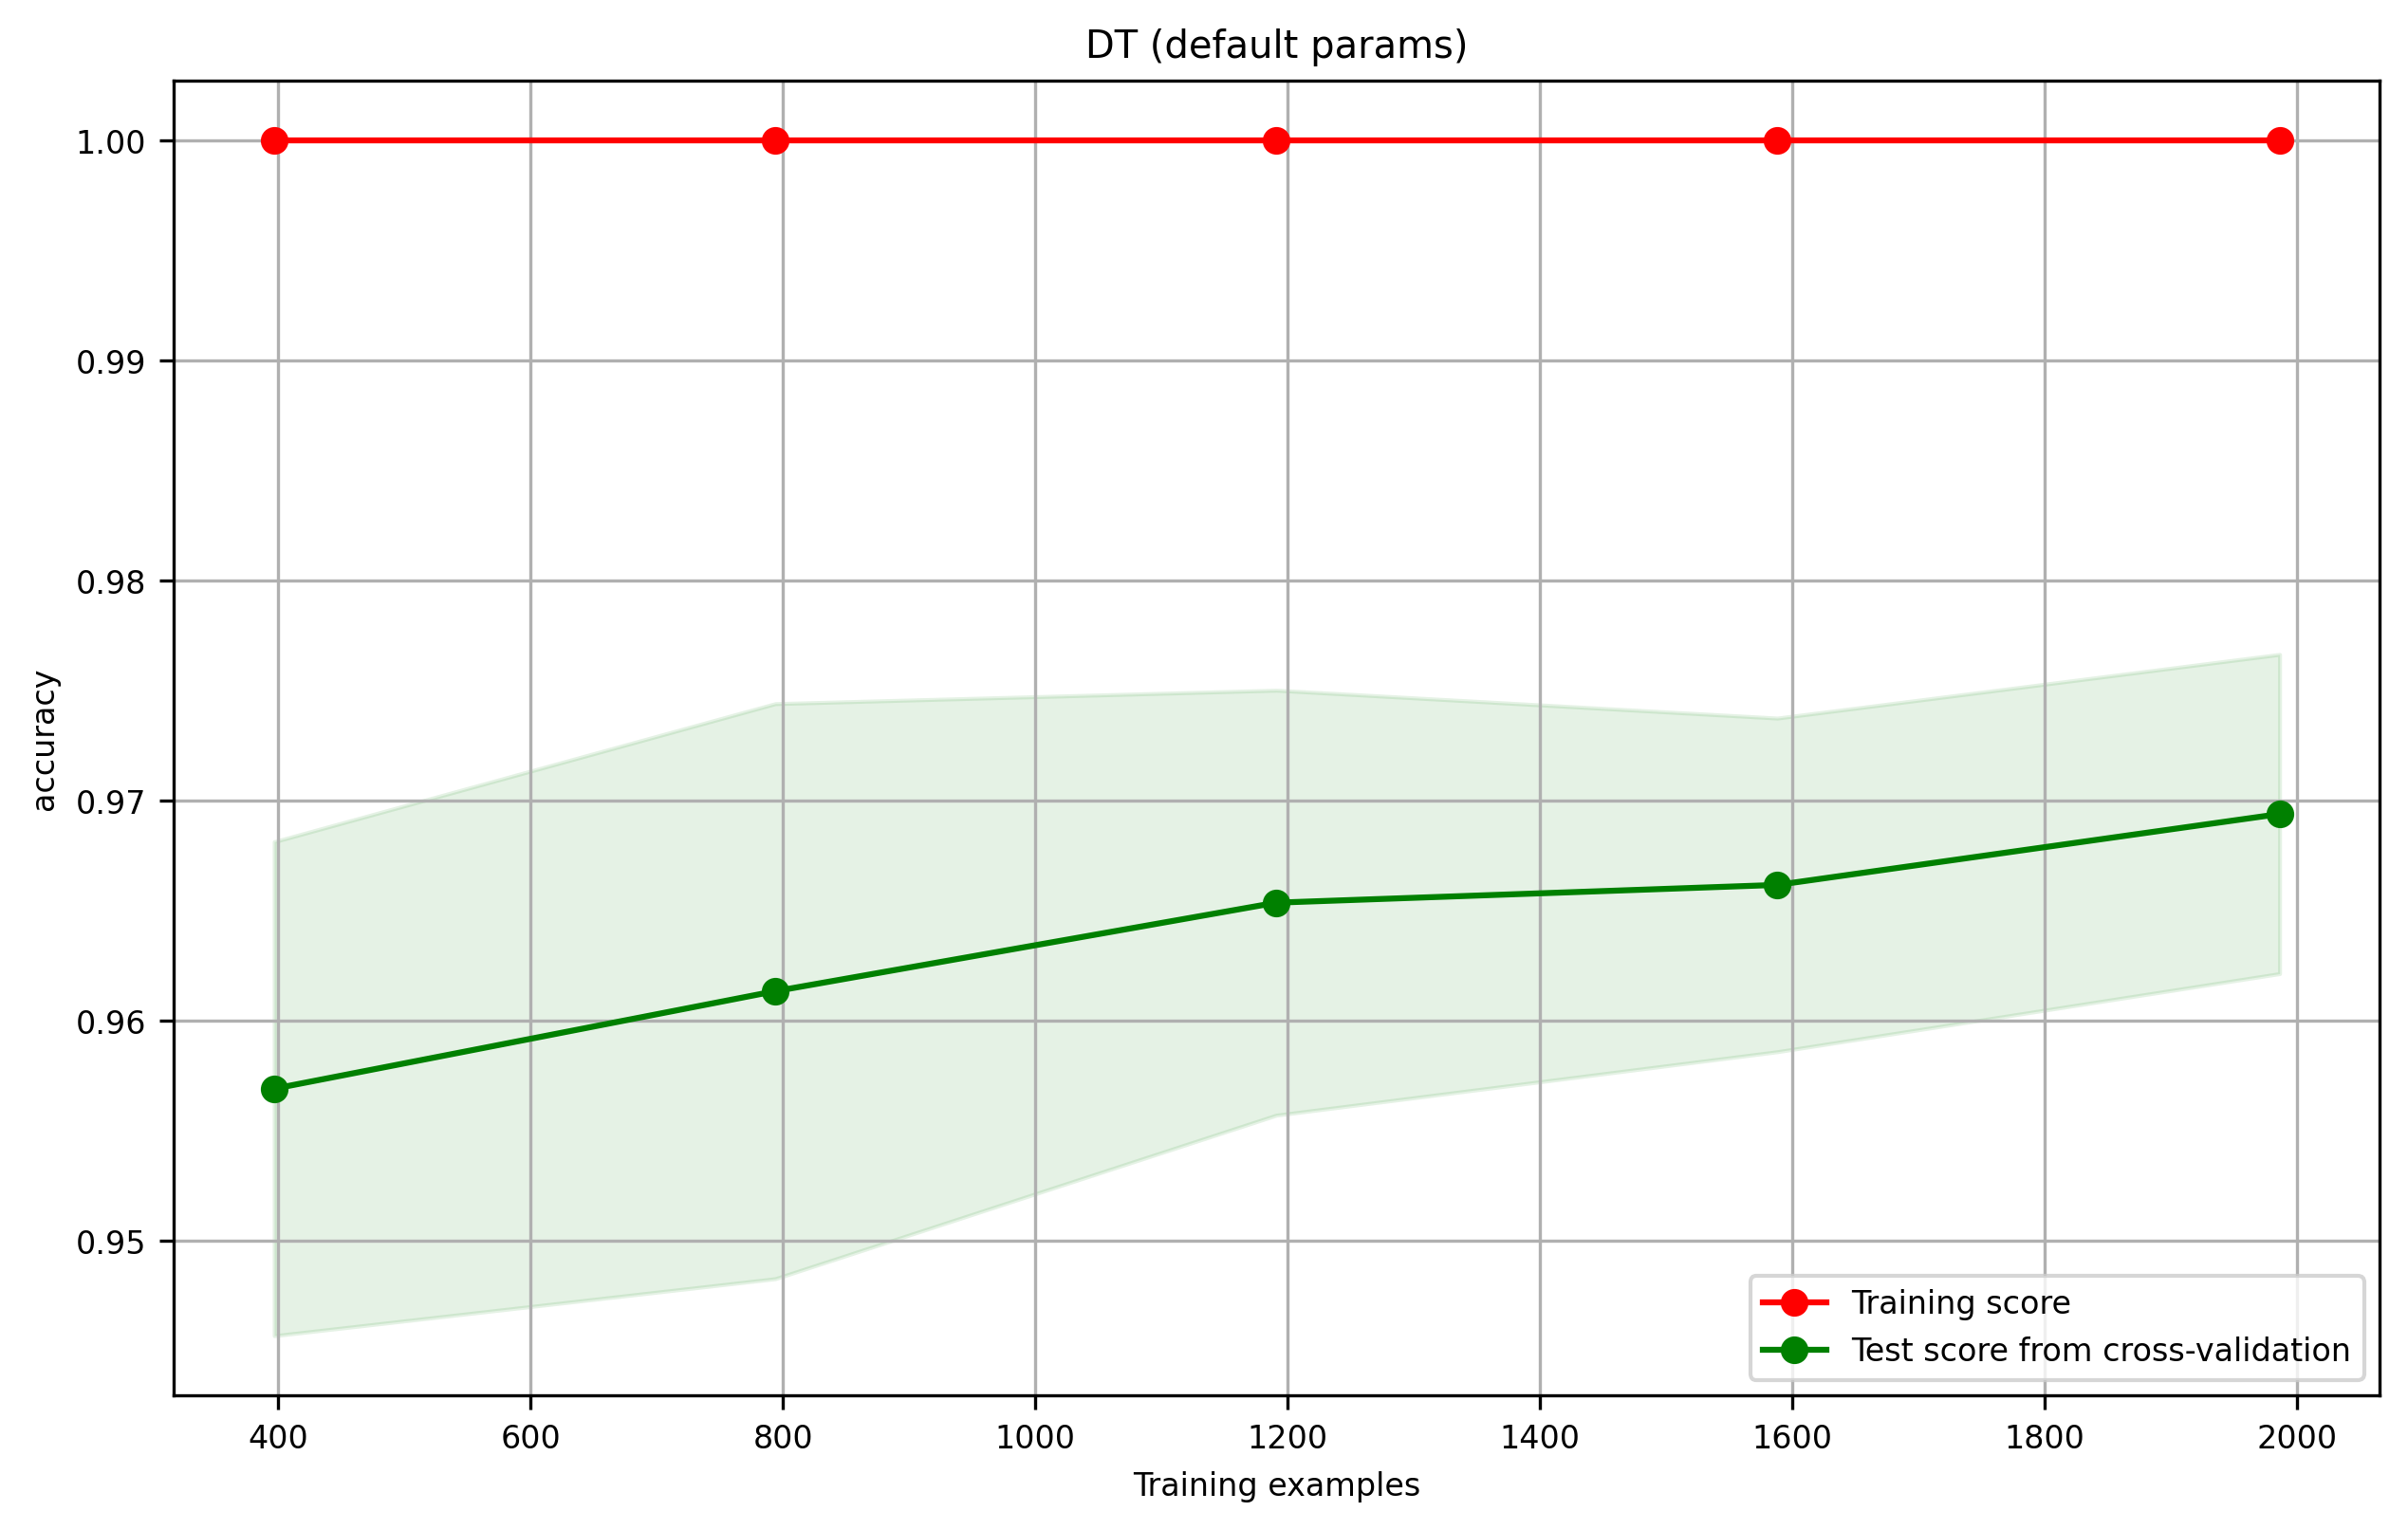

In [103]:
plot_learning_curve(model, 'DT (default params)', X, y,  cv = cv3, scoring = 'accuracy');

### **Preguntas**

Responda brevemente:

1. ¿Existe una brecha entre la curva de entrenamiento y la de validación? ¿Qué sugiere eso?
2. ¿El rendimiento de validación mejora al agregar más ejemplos?
3. ¿Hablaría aquí de alto sesgo, alta varianza o sobreajuste moderado? Justifique.
4. Escriba una conclusión general sobre el comportamiento del árbol base a partir de estas curvas.

**RESPUESTAS**

1. Si hay una brecha, la curva roja se mantiene constante en 1 mientras que la verde cambia constantemente, esto quiere decir que el modelo no esta clasificando de buena manera

2. Si mejora al agregar más ejemplos, ya que las curvas comienzan a aumentar mientras se aumenta los trininig examples.

3. Tenemos alta varianza y sobreajuste cte, ya que no hay error de entrenamiento y hay una gran brecha entre el error de validación. Esto quiere decir que el modelo es sensible a los cambios.

4. El arbol crece de forma rápida y constante, esto hace que se sobreajuste la muestra. Aunque utilizar más datosw de prueba ayuda, el tamaño de la muestra es tan alto que no ayuda del todo.

### Desafío: ¿un árbol más simple generaliza mejor?

Entrene ahora un segundo árbol, más restringido que el árbol base. Por ejemplo, puede probar con:

- `max_depth=3`, o
- `min_samples_leaf=10`

Luego compare su rendimiento con el árbol base usando:

- accuracy
- precision
- recall
- F1-score



### Preguntas

A partir de los resultados obtenidos con validación cruzada:

1. ¿Qué ocurrió con el rendimiento al restringir la complejidad del árbol?
2. ¿El árbol más simple empeoró o mejoró la generalización?
3. ¿Qué sugieren estos resultados sobre el árbol base?
4. En este problema, ¿parece conveniente usar el árbol sin restricciones?
5. ¿Qué métrica le parece más importante para decidir entre ambos modelos?

In [104]:
#Entrnando el nuevo arbol.
from sklearn.tree import DecisionTreeClassifier

modelo_simple = DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, random_state=42)
modelo_simple.fit(X_train, y_train)
modelo_simple.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, random_state=42)

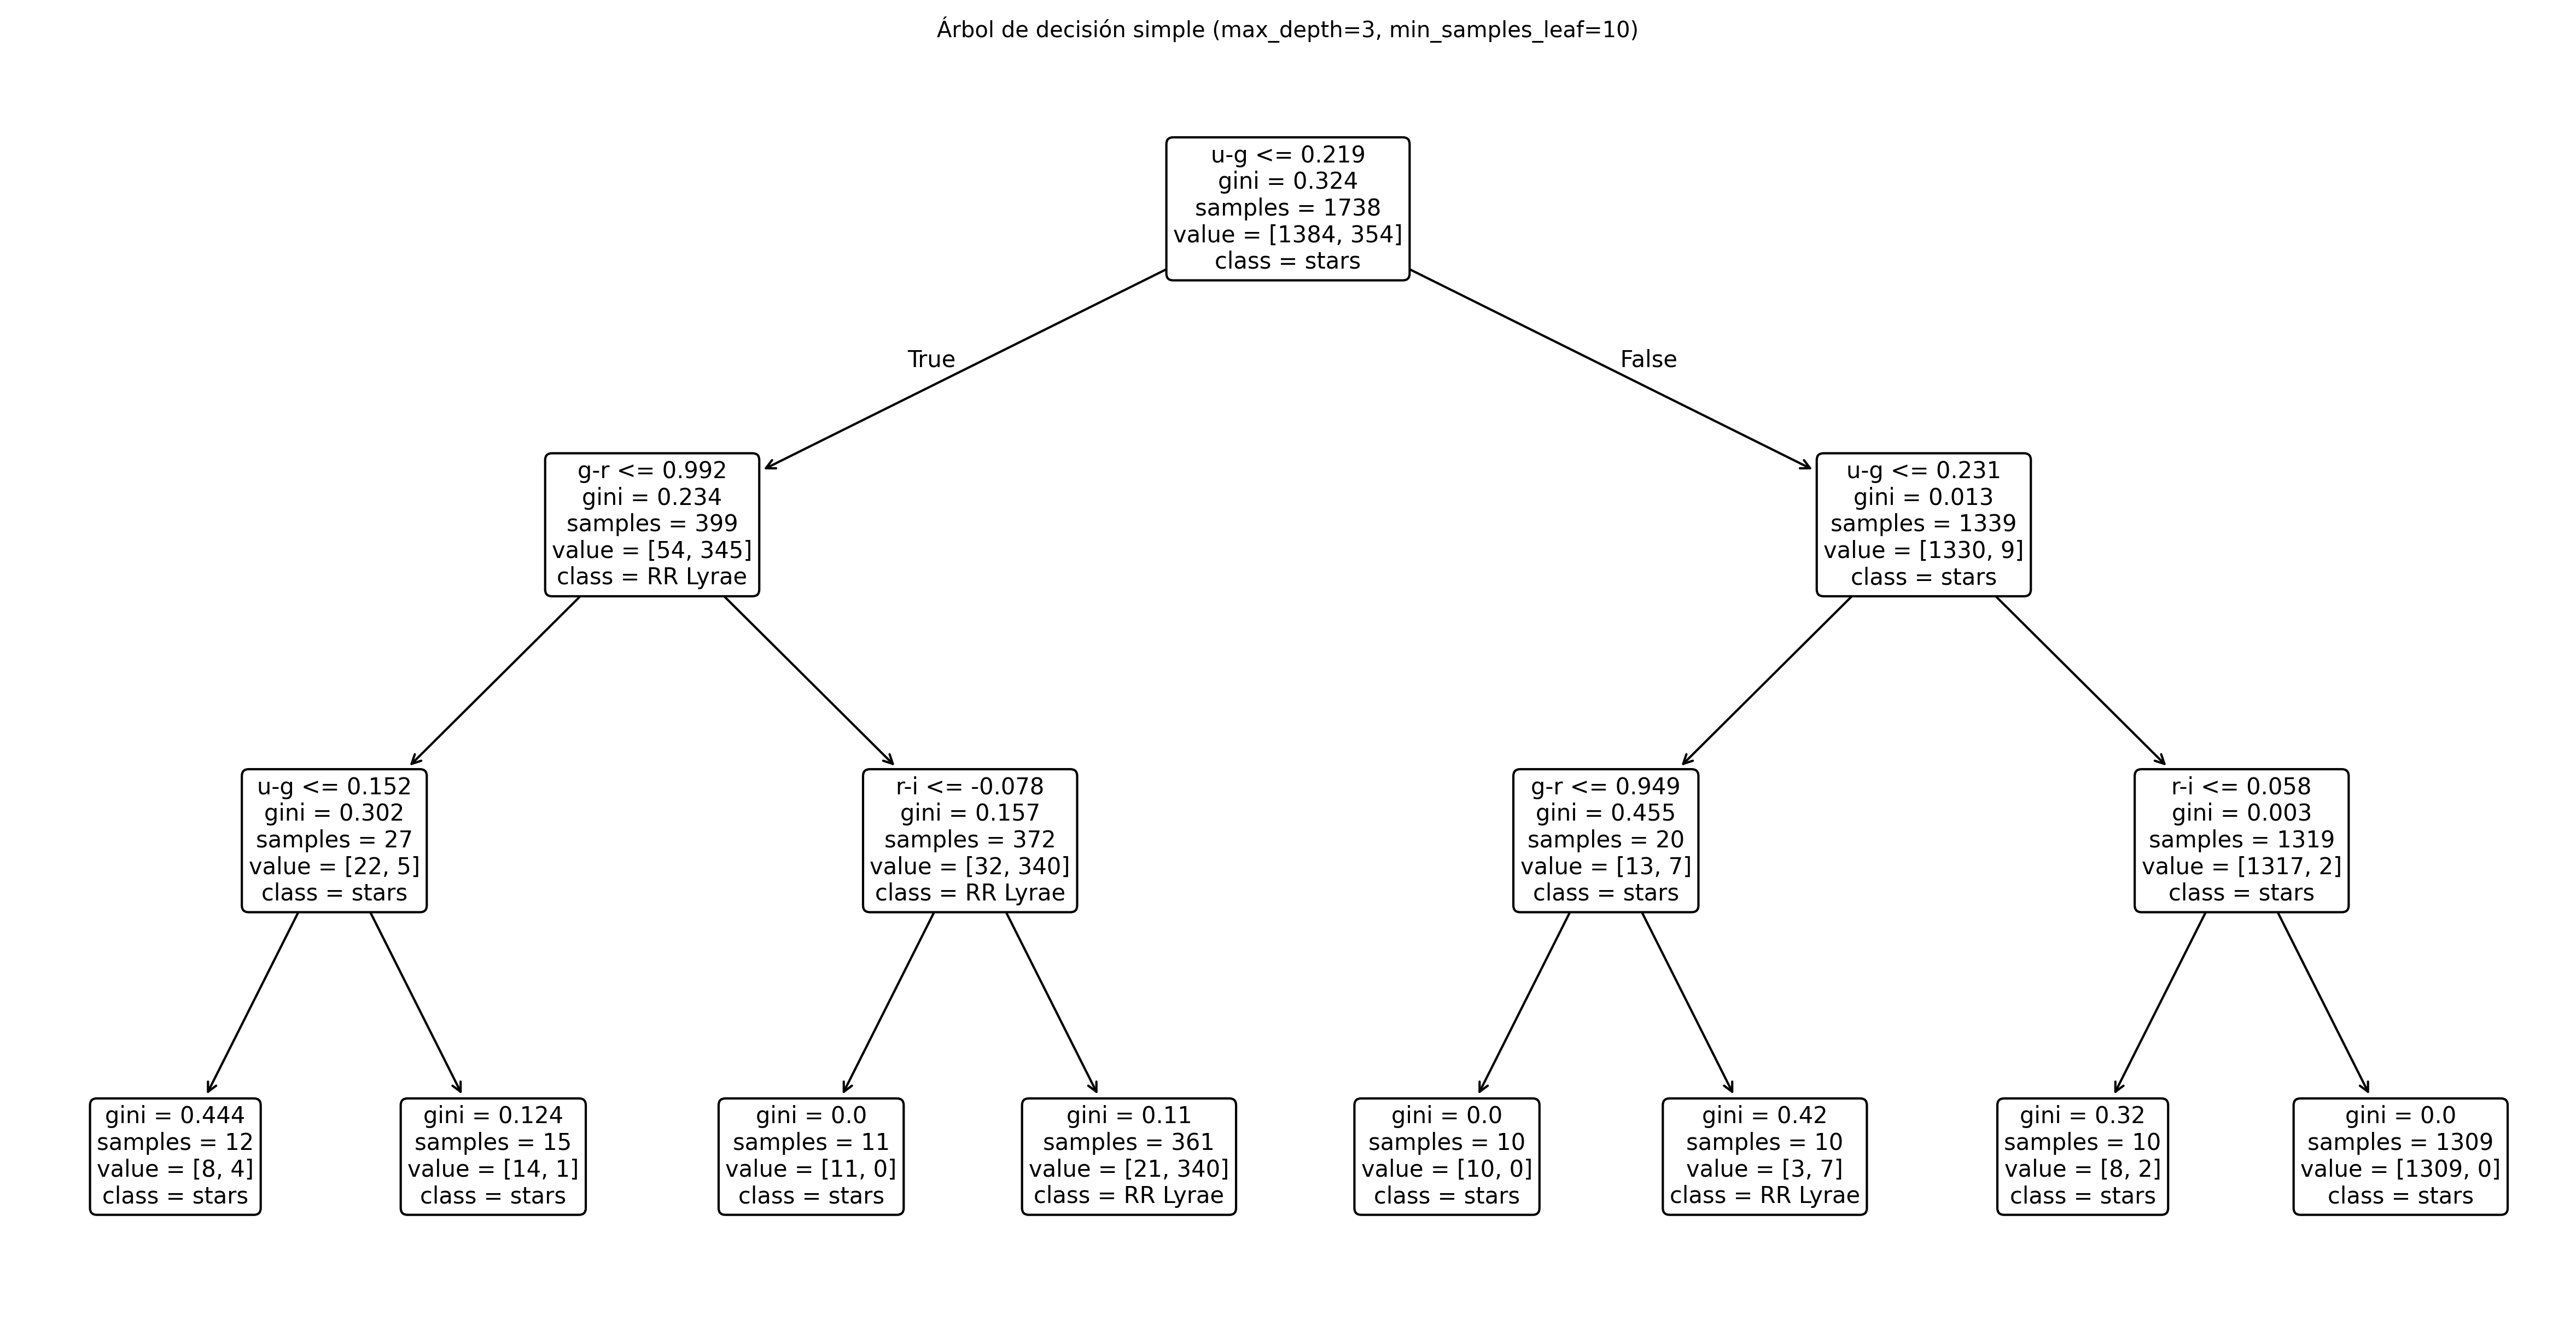

In [105]:
#para graficar el nuevo arbol
plt.figure(figsize=(20,10))

plot_tree(
    modelo_simple,
    feature_names=X.columns,
    class_names=["stars", "RR Lyrae"],
    filled=False,
    rounded=True,
    fontsize=10
)

plt.title("Árbol de decisión simple (max_depth=3, min_samples_leaf=10)")
plt.show()

In [106]:
y_pred_simple = modelo_simple.predict(X_test)

accuracy = metrics.accuracy_score(y_test, y_pred_simple)
precision = metrics.precision_score(y_test, y_pred_simple)
recall = metrics.recall_score(y_test, y_pred_simple)
f1 = metrics.f1_score(y_test, y_pred_simple)

print("Métricas del Árbol Restringido (Podado):")
print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")

Métricas del Árbol Restringido (Podado):
Accuracy:  0.970
Precision: 0.896
Recall:    0.938
F1-score:  0.917


In [107]:
#para comparar las metricas genero una tabla
datos_comparacion = {
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Árbol Base (Complejo)': [0.965, 0.876, 0.930, 0.902],
    'Árbol Restringido (Simple)': [accuracy, precision, recall, f1]
}

tabla_metricas = pd.DataFrame(datos_comparacion)

tabla_metricas

,Métrica,Árbol Base (Complejo),Árbol Restringido (Simple)
0,Accuracy,0.965,0.970470
1,Precision,0.876,0.896296
2,Recall,0.930,0.937984
3,F1-Score,0.902,0.916667


**RESPUESTAS**

1. En general el rendimiento mejoró en todo, no de una forma marcada pero si aumenta unos decimales.

2. El arbol más simple mejoro la generalización, ya que limitamos la profundidad, y definimo un minimo de muestras por hoja, el modelo dejo de memorizar.

3. Los resultados confirman que el árbol base tenía sobreajuste.

4. No conviene en lo absoluto usar el arbol base, el arbol simple es más compacto (más ligero para predecir datos) por lo que deberia ser más facil y rápido usarlo, ademas todos las metricas del arbol pequeño fueron mejores, por lo que en ningun caso es mejor usar el arbol base.

5. El F1 es la métrica más completa para comparar ambos modelos, ya que este relaciona los falsos negativos y positivos. Aun así dependera de cual es la meta de la investigación, por ejemplo si no quieres perder estrellas lo mejor será fijarse en el recall.

## Desafío: comparar con kNN

Hasta ahora trabajamos con árboles de decisión. Ahora comparemos ese enfoque con un clasificador distinto: **k-Nearest Neighbors (kNN)**.

Entrene un modelo kNN y compárelo con el árbol simple usando validación cruzada estratificada. Recuerde que kNN está basado en distancias, por lo que antes de entrenarlo debe escalar las variables.

### Instrucciones

1. Entrene un modelo kNN con `k=5`.
2. Use un `StandardScaler` antes del clasificador.
3. Evalúe el modelo con validación cruzada estratificada usando:
   - accuracy
   - precision
   - recall
   - F1-score
4. Compare sus resultados con los del árbol simple.
5. Luego explore distintos valores de `k` y vea cómo cambian las métricas.

### Preguntas

1. ¿Cómo se compara el rendimiento de kNN con el del árbol simple?
2. ¿Qué ocurre cuando `k` es muy pequeño?
3. ¿Qué ocurre cuando `k` es muy grande?
4. ¿Qué valor de `k` parece dar el mejor equilibrio entre precision y recall?
5. ¿Qué ventaja podría tener kNN si la frontera entre clases no es rectangular?

In [108]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelo_knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))

metricas = ['accuracy', 'precision', 'recall', 'f1']

resultados_knn = cross_validate(modelo_knn, features, targets, cv=skf, scoring=metricas)

from sklearn.tree import DecisionTreeClassifier
modelo_simple = DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, random_state=42)
resultados_dt = cross_validate(modelo_simple, features, targets, cv=skf, scoring=metricas)

print("--- Resultados kNN (k=5, Datos Escalados) ---")
print(f"Accuracy:  {resultados_knn['test_accuracy'].mean():.3f}")
print(f"Precision: {resultados_knn['test_precision'].mean():.3f}")
print(f"Recall:    {resultados_knn['test_recall'].mean():.3f}")
print(f"F1-score:  {resultados_knn['test_f1'].mean():.3f}\n")

print("--- Resultados Árbol Restringido (max_depth=3, min_samples_leaf=10) ---")
print(f"Accuracy:  {resultados_dt['test_accuracy'].mean():.3f}")
print(f"Precision: {resultados_dt['test_precision'].mean():.3f}")
print(f"Recall:    {resultados_dt['test_recall'].mean():.3f}")
print(f"F1-score:  {resultados_dt['test_f1'].mean():.3f}")

--- Resultados kNN (k=5, Datos Escalados) ---
Accuracy:  0.978
Precision: 0.926
Recall:    0.967
F1-score:  0.946

--- Resultados Árbol Restringido (max_depth=3, min_samples_leaf=10) ---
Accuracy:  0.972
Precision: 0.913
Recall:    0.948
F1-score:  0.930


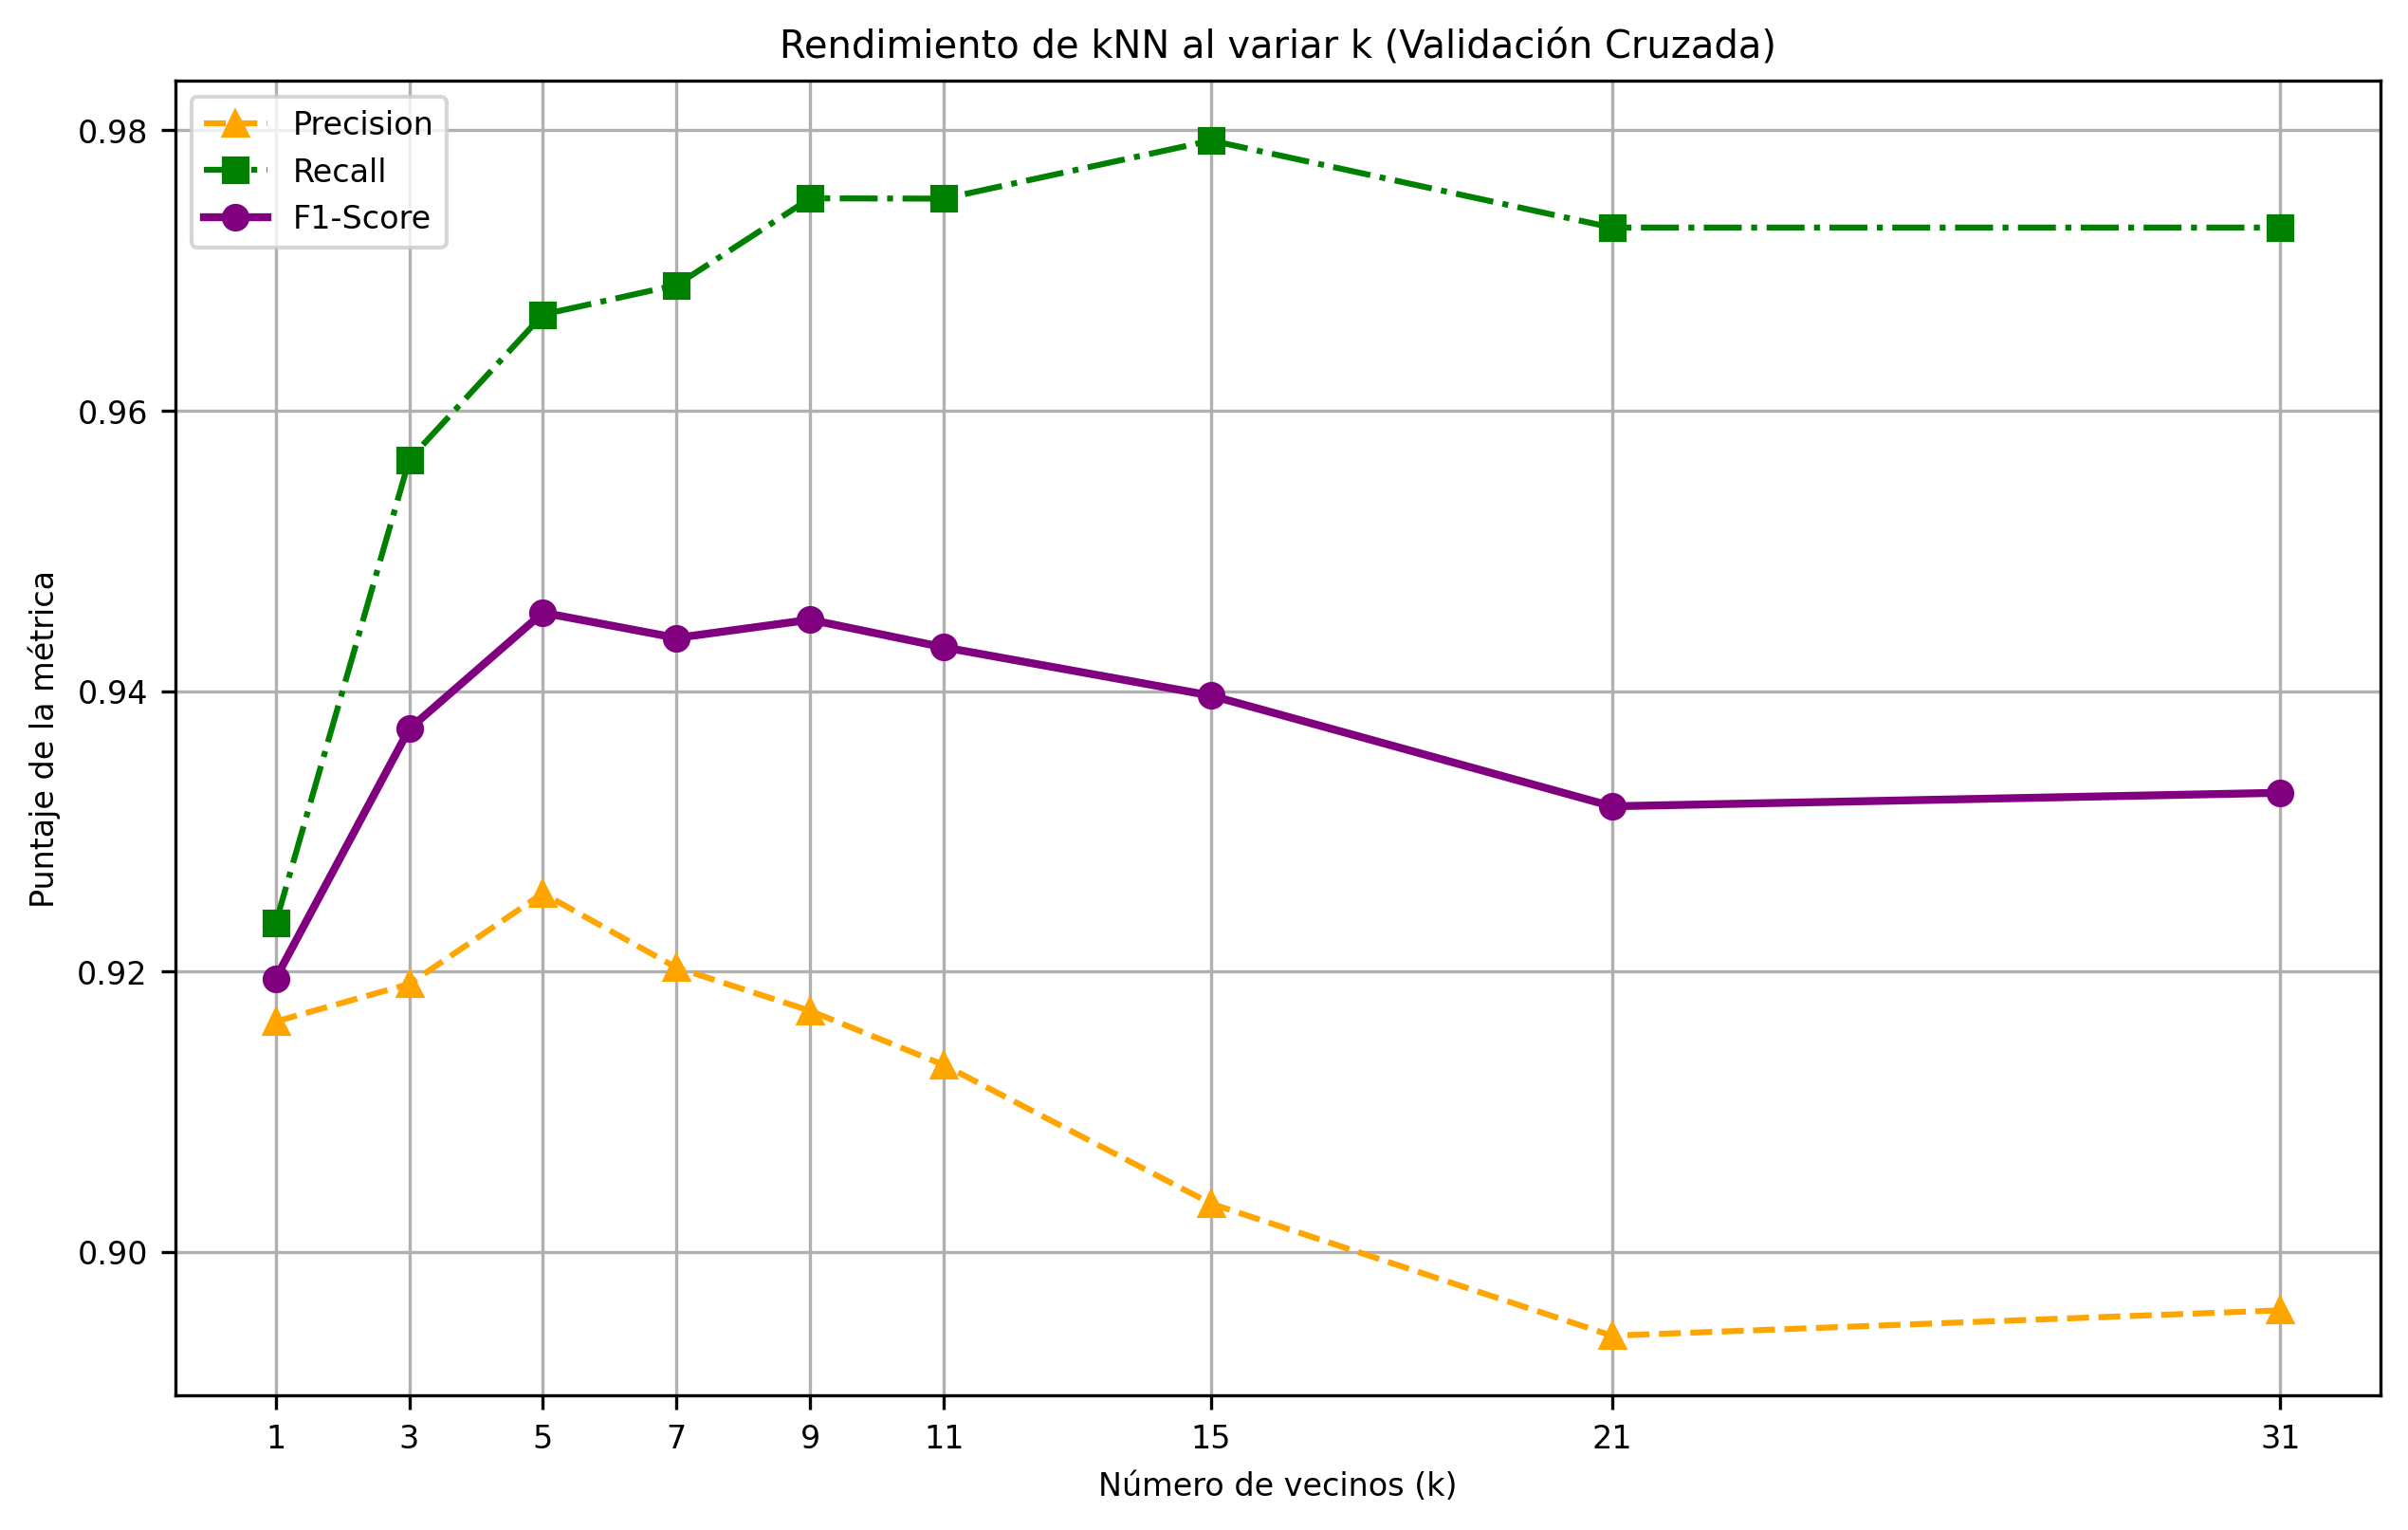

In [109]:
import matplotlib.pyplot as plt

# Definimos una lista con los valores de k que queremos probar
valores_k = [1, 3, 5, 7, 9, 11, 15, 21, 31]

# Listas vacías para ir guardando los resultados promedio de cada iteración
lista_precision = []
lista_recall = []
lista_f1 = []

# Bucle para probar cada valor de k
for k in valores_k:

    modelo_knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))

    cv_res = cross_validate(modelo_knn, features, targets, cv=skf, scoring=['precision', 'recall', 'f1'])

    lista_precision.append(cv_res['test_precision'].mean())
    lista_recall.append(cv_res['test_recall'].mean())
    lista_f1.append(cv_res['test_f1'].mean())

plt.figure(figsize=(10, 6))

plt.plot(valores_k, lista_precision, marker='^', label='Precision', color='orange', linestyle='--')
plt.plot(valores_k, lista_recall, marker='s', label='Recall', color='green', linestyle='-.')
plt.plot(valores_k, lista_f1, marker='o', label='F1-Score', color='purple', linewidth=2)

plt.xlabel('Número de vecinos (k)')
plt.ylabel('Puntaje de la métrica')
plt.title('Rendimiento de kNN al variar k (Validación Cruzada)')
plt.xticks(valores_k)
plt.legend()
plt.grid(True)
plt.show()

**RESPUESTAS**

1. El modelo kNN es mejor que el árbol de decisión simple, todas las métricas son mayores. Por lo que funciona mejor como modelo de predicción.

2. Si k es muy pequeño, el modelo de vuelve muy sensible ya que tiene alta varianza o sobreajuste. Tal como he mencionado, aquí es cuando el modelo no predice, más bien memoriza.

3. Cuando k es muy grande hay un alto sesgo (subajuste). La Precisión disminuye, lo que significa que aumentan los falsos positivos, también hay un descenso en el F1, ya que el modelo pierde la capacidad de distinguir los detalles finos de la clase pequeña.

4. El mejor equilibrio se da en k=5 ya que proporciona el mejor rendimiento. En este punto, la curva del F1 alcanza su pico máximo absoluto, esto significa que se logra un recall y una precision alta al mismo tiempo, encontrando un equilibrio.

5. Los árboles de decisión solo pueden segmentar el espacio mediante cortes rectos repetidamente y en direcciones horizontales o verticales, por lo que se segmentan en cuadrados. kNN, tiene la flexibilidad de generar fronteras de decisión curvas, diagonales o con formas irregulares.

## Cierre

En esta actividad vimos que evaluar un clasificador no consiste solo en obtener un score alto, sino en interpretar qué está midiendo cada métrica y cómo se construyen los conjuntos de validación. En este problema, el uso de validación cruzada estratificada fue importante para obtener una evaluación más estable y representativa.

También observamos que un modelo más complejo no siempre generaliza mejor. Aunque el árbol base ajustaba perfectamente los datos de entrenamiento, un árbol más simple logró mejores resultados en validación cruzada, lo que sugiere que reducir la complejidad ayudó a disminuir el sobreajuste.